# DDPM v2 — dogs, 32×32 RGB

[Ho, Jain & Abbeel (2020)](https://arxiv.org/abs/2006.11239)

CIFAR-10, dog class only. 5000 images, 3 channels, self-attention in the U-Net, EMA weights.

Runtime → Change runtime type → T4 GPU. About 45 minutes.

In [ ]:
import math, time, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__, device)

2.11.0+cu128 cuda


In [ ]:
T          = 1000
BETA_START = 1e-4
BETA_END   = 0.02
EPOCHS     = 500
BATCH      = 128
LR         = 2e-4
IMG        = 32
CH         = 3
EMA_DECAY  = 0.9995
torch.manual_seed(0)

$$\alpha_t = 1-\beta_t \qquad \bar\alpha_t = \prod_{s=1}^{t}\alpha_s$$

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon, \qquad \epsilon\sim\mathcal{N}(0,I)$$

In [ ]:
betas           = torch.linspace(BETA_START, BETA_END, T, device=device)
alphas          = 1.0 - betas
abar            = torch.cumprod(alphas, dim=0)
sqrt_abar       = abar.sqrt()
sqrt_one_m_abar = (1.0 - abar).sqrt()

def q_sample(x0, t, eps):
    return sqrt_abar[t].view(-1, 1, 1, 1) * x0 + sqrt_one_m_abar[t].view(-1, 1, 1, 1) * eps

print(abar[0].item(), abar[-1].item())

0.9998999834060669 4.035829260828905e-05


100%|██████████| 170M/170M [26:26<00:00, 107kB/s]


5000


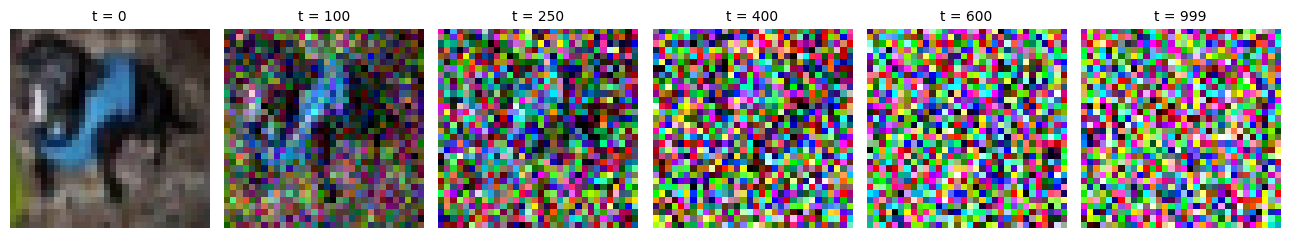

In [ ]:
tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,) * 3, (0.5,) * 3),
])
full   = datasets.CIFAR10(root="./data", train=True, download=True, transform=tf)
dogs   = Subset(full, np.where(np.array(full.targets) == 5)[0])
loader = DataLoader(dogs, batch_size=BATCH, shuffle=True, num_workers=2,
                    drop_last=True, pin_memory=True)
print(len(dogs))

x0 = dogs[0][0].unsqueeze(0).to(device)
steps = [0, 100, 250, 400, 600, 999]
fig, axes = plt.subplots(1, len(steps), figsize=(13, 2.6))
for ax, s in zip(axes, steps):
    xt = q_sample(x0, torch.tensor([s], device=device), torch.randn_like(x0))
    ax.imshow(((xt[0].clamp(-1, 1) + 1) / 2).permute(1, 2, 0).cpu())
    ax.set_title(f"t = {s}", fontsize=10)
    ax.axis("off")
plt.tight_layout(); plt.savefig("forward.png", dpi=130, bbox_inches="tight"); plt.show()

$$\epsilon_\theta(x_t,\ t)$$

In [ ]:
def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device).float() / half)
    args = t.float()[:, None] * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)


class Attention(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.norm = nn.GroupNorm(8, c)
        self.qkv  = nn.Conv2d(c, c * 3, 1)
        self.proj = nn.Conv2d(c, c, 1)

    def forward(self, x):
        B, Cc, H, W = x.shape
        q, k, v = self.qkv(self.norm(x)).reshape(B, 3, Cc, H * W).unbind(1)
        a = torch.softmax(q.transpose(1, 2) @ k / math.sqrt(Cc), dim=-1)
        o = (v @ a.transpose(1, 2)).reshape(B, Cc, H, W)
        return x + self.proj(o)


class ResBlock(nn.Module):
    def __init__(self, c_in, c_out, t_dim):
        super().__init__()
        self.norm1  = nn.GroupNorm(8, c_in)
        self.conv1  = nn.Conv2d(c_in, c_out, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, c_out)
        self.norm2  = nn.GroupNorm(8, c_out)
        self.drop   = nn.Dropout(0.1)
        self.conv2  = nn.Conv2d(c_out, c_out, 3, padding=1)
        self.skip   = nn.Conv2d(c_in, c_out, 1) if c_in != c_out else nn.Identity()

    def forward(self, x, temb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(temb))[:, :, None, None]
        h = self.conv2(self.drop(F.silu(self.norm2(h))))
        return h + self.skip(x)


class UNet(nn.Module):
    def __init__(self, base=96, t_dim=384):
        super().__init__()
        self.t_dim = t_dim
        self.t_mlp = nn.Sequential(
            nn.Linear(t_dim // 2, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))
        c1, c2, c3 = base, base * 2, base * 4

        self.inc   = nn.Conv2d(CH, c1, 3, padding=1)
        self.rb1   = ResBlock(c1, c1, t_dim)
        self.down1 = nn.Conv2d(c1, c1, 3, stride=2, padding=1)
        self.rb2   = ResBlock(c1, c2, t_dim)
        self.at2   = Attention(c2)
        self.down2 = nn.Conv2d(c2, c2, 3, stride=2, padding=1)
        self.mid1  = ResBlock(c2, c3, t_dim)
        self.atm   = Attention(c3)
        self.mid2  = ResBlock(c3, c2, t_dim)
        self.up1   = ResBlock(c2 + c2, c1, t_dim)
        self.at3   = Attention(c1)
        self.up2   = ResBlock(c1 + c1, c1, t_dim)
        self.out   = nn.Sequential(
            nn.GroupNorm(8, c1), nn.SiLU(), nn.Conv2d(c1, CH, 3, padding=1))

    def forward(self, x, t):
        temb = self.t_mlp(timestep_embedding(t, self.t_dim // 2))
        h1 = self.rb1(self.inc(x), temb)
        h2 = self.at2(self.rb2(self.down1(h1), temb))
        m  = self.mid2(self.atm(self.mid1(self.down2(h2), temb)), temb)
        u  = F.interpolate(m, scale_factor=2, mode="nearest")
        u  = self.at3(self.up1(torch.cat([u, h2], dim=1), temb))
        u  = F.interpolate(u, scale_factor=2, mode="nearest")
        u  = self.up2(torch.cat([u, h1], dim=1), temb)
        return self.out(u)


model = UNet().to(device)
ema   = copy.deepcopy(model).eval().requires_grad_(False)
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

with torch.no_grad():
    d = torch.randn(4, CH, IMG, IMG, device=device)
    s = model(d, torch.randint(0, T, (4,), device=device)).shape
    assert s == d.shape, s
print(tuple(s))

6.37M
(4, 3, 32, 32)


$$L_{\text{simple}} = \mathbb{E}_{t,\,x_0,\,\epsilon}\Big[\big\|\,\epsilon - \epsilon_\theta\big(\sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon,\ t\big)\big\|^2\Big]$$

   1/500  0.3099  9.9s
  10/500  0.0517  12.1s
  20/500  0.0428  11.5s
  30/500  0.0392  11.8s
  40/500  0.0364  11.8s
  50/500  0.0367  11.7s
  60/500  0.0361  11.7s
  70/500  0.0363  11.7s
  80/500  0.0373  11.7s
  90/500  0.0343  11.7s
 100/500  0.0361  11.8s
 110/500  0.0335  11.6s
 120/500  0.0342  11.7s
 130/500  0.0352  11.7s
 140/500  0.0327  11.8s
 150/500  0.0325  11.7s
 160/500  0.0329  11.7s
 170/500  0.0322  11.6s
 180/500  0.0308  11.4s
 190/500  0.0312  11.8s
 200/500  0.0331  11.8s
 210/500  0.0322  11.7s
 220/500  0.0322  11.7s
 230/500  0.0318  11.8s
 240/500  0.0325  11.8s
 250/500  0.0326  11.5s
 260/500  0.0305  11.8s
 270/500  0.0318  11.7s
 280/500  0.0340  11.9s
 290/500  0.0312  11.4s
 300/500  0.0316  11.9s
 310/500  0.0306  11.6s
 320/500  0.0320  11.6s
 330/500  0.0320  11.8s
 340/500  0.0313  11.6s
 350/500  0.0310  11.7s
 360/500  0.0312  11.6s
 370/500  0.0306  11.8s
 380/500  0.0319  11.8s
 390/500  0.0304  11.8s
 400/500  0.0327  11.7s
 410/500  0.0308 

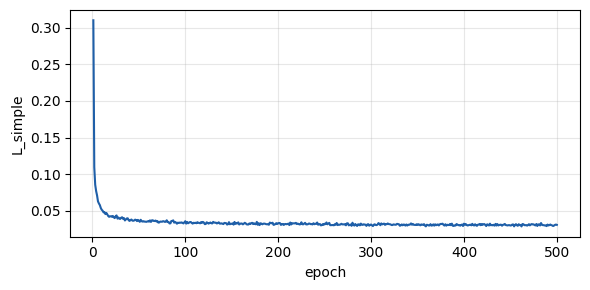

In [ ]:
opt = torch.optim.Adam(model.parameters(), lr=LR)
losses = []


@torch.no_grad()
def ema_update(m, e, d=EMA_DECAY):
    for pe, pm in zip(e.parameters(), m.parameters()):
        pe.mul_(d).add_(pm.detach(), alpha=1 - d)
    for be, bm in zip(e.buffers(), m.buffers()):
        be.copy_(bm)


model.train()
for epoch in range(1, EPOCHS + 1):
    t0, run, seen = time.time(), 0.0, 0
    for x0, _ in loader:
        x0 = x0.to(device, non_blocking=True)
        t   = torch.randint(0, T, (x0.size(0),), device=device)
        eps = torch.randn_like(x0)
        loss = F.mse_loss(model(q_sample(x0, t, eps), t), eps)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        ema_update(model, ema)
        run  += loss.item() * x0.size(0)
        seen += x0.size(0)
    losses.append(run / seen)
    if epoch == 1 or epoch % 10 == 0:
        print(f"{epoch:4d}/{EPOCHS}  {losses[-1]:.4f}  {time.time() - t0:.1f}s")

plt.figure(figsize=(6, 3))
plt.plot(range(1, len(losses) + 1), losses, color="#1F5FA8")
plt.xlabel("epoch"); plt.ylabel("L_simple"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("loss.png", dpi=130); plt.show()

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Big(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\epsilon_\theta(x_t,t)\Big) + \sigma_t z$$

In [ ]:
@torch.no_grad()
def sample(net, n, keep_every=50):
    net.eval()
    x = torch.randn(n, CH, IMG, IMG, device=device)
    traj, ts = [], []
    for i in reversed(range(T)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps  = net(x, t)
        mean = (x - betas[i] / sqrt_one_m_abar[i] * eps) / alphas[i].sqrt()
        x = mean + betas[i].sqrt() * torch.randn_like(x) if i > 0 else mean
        if i % keep_every == 0:
            traj.append(x.clone())
            ts.append(i)
    return x, traj, ts


def show(imgs, title, fname, nrow=8):
    g = make_grid((imgs.clamp(-1, 1) + 1) / 2, nrow=nrow, padding=2)
    plt.figure(figsize=(nrow * 1.3, imgs.size(0) / nrow * 1.35 + 0.6))
    plt.imshow(g.permute(1, 2, 0).cpu()); plt.title(title); plt.axis("off")
    plt.tight_layout(); plt.savefig(fname, dpi=140, bbox_inches="tight"); plt.show()


t0 = time.time()
imgs, traj, ts = sample(ema, 64, keep_every=50)
print(f"{time.time() - t0:.0f}s")
show(imgs, "dogs from pure noise", "samples.png", nrow=8)

Reverse process every 50 steps, $t = 950 \rightarrow 0$.

In [ ]:
k = 4
fig, axes = plt.subplots(k, len(traj), figsize=(len(traj) * 0.82, k * 0.95))
for r in range(k):
    for c, (frame, tt) in enumerate(zip(traj, ts)):
        ax = axes[r, c]
        ax.imshow(((frame[r].clamp(-1, 1) + 1) / 2).permute(1, 2, 0).cpu())
        ax.axis("off")
        if r == 0:
            ax.set_title(str(tt), fontsize=7)
plt.tight_layout(); plt.savefig("trajectory.png", dpi=150, bbox_inches="tight"); plt.show()